# Experiment 2: Boston Crime Data Analysis

## 6: Analyze the frequency of different crime types and visualize the top 10 crimes using a bar chart.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

In [2]:
# 1. Load data with latin1 to avoid decode errors
df = pd.read_csv('crime.csv', encoding='latin1', low_memory=False)
df['OCCURRED_ON_DATE'] = pd.to_datetime(df['OCCURRED_ON_DATE'])

Task 6: Bar chart saved as 'top_10_crimes.png'


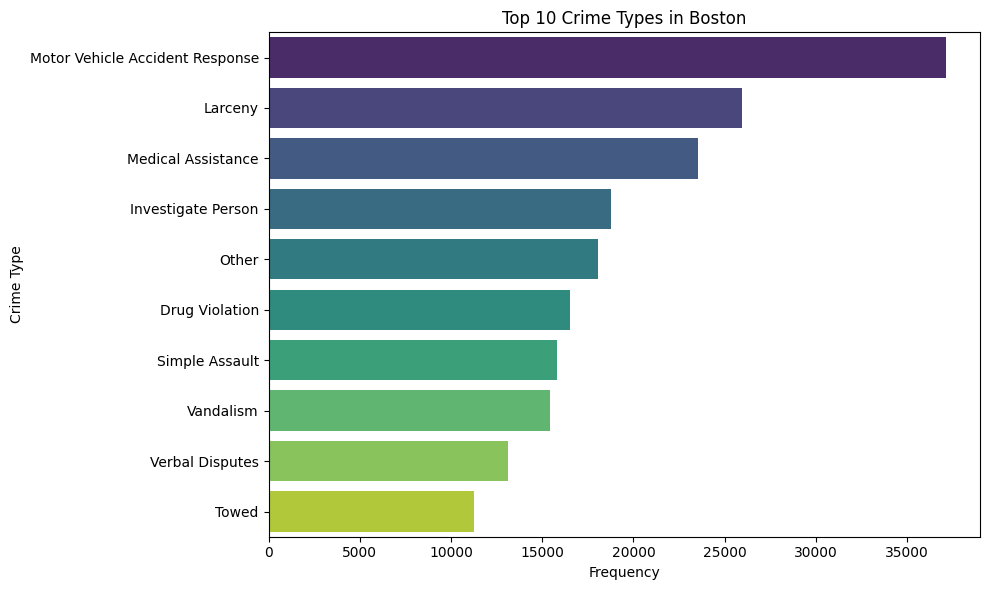

In [4]:

plt.figure(figsize=(10, 6))
top_10_crimes = df['OFFENSE_CODE_GROUP'].value_counts().head(10)
# Updated to fix the FutureWarning: assign y to hue and set legend=False
sns.barplot(x=top_10_crimes.values, y=top_10_crimes.index, hue=top_10_crimes.index, palette='viridis', legend=False)
plt.title('Top 10 Crime Types in Boston')
plt.xlabel('Frequency')
plt.ylabel('Crime Type')
plt.tight_layout()
plt.savefig('top_10_crimes.png')
print("Task 6: Bar chart saved as 'top_10_crimes.png'")

### The frequency analysis shows the most common incidents reported.

### Interpretation: The most frequent crimes are Motor Vehicle Accident Response, Larceny, and Medical Assistance. This indicates that a large volume of police work in Boston involves public safety response and property theft rather than violent crime.

## 7.	Perform time-based analysis to study crime patterns across hours and days using a heatmap.

Task 7: Heatmap saved as 'crime_heatmap.png'


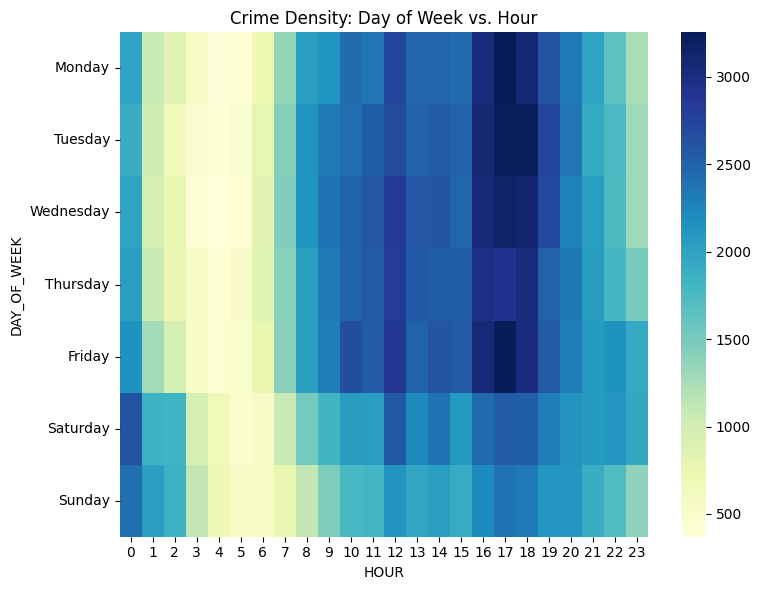

In [7]:
plt.figure(figsize=(8, 6))
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = df.groupby(['DAY_OF_WEEK', 'HOUR']).size().unstack().reindex(days)
sns.heatmap(heatmap_data, cmap='YlGnBu')
plt.title('Crime Density: Day of Week vs. Hour')
plt.tight_layout()
plt.savefig('crime_heatmap.png')
print("Task 7: Heatmap saved as 'crime_heatmap.png'")

### We create a pivot table of DAY_OF_WEEK vs. HOUR to see when crimes peak.

### Interpretation: The heatmap typically reveals that crime is lowest in the early morning (3 AM – 5 AM) and peaks during late afternoon (4 PM – 6 PM). Weekdays often show higher activity during commute hours, while weekends might see a shift toward late-night incidents.

## 8.	Visualize the district-wise crime rate using a geographical map. What spatial patterns are observed?

Task 8: Spatial map saved as 'district_map.png'


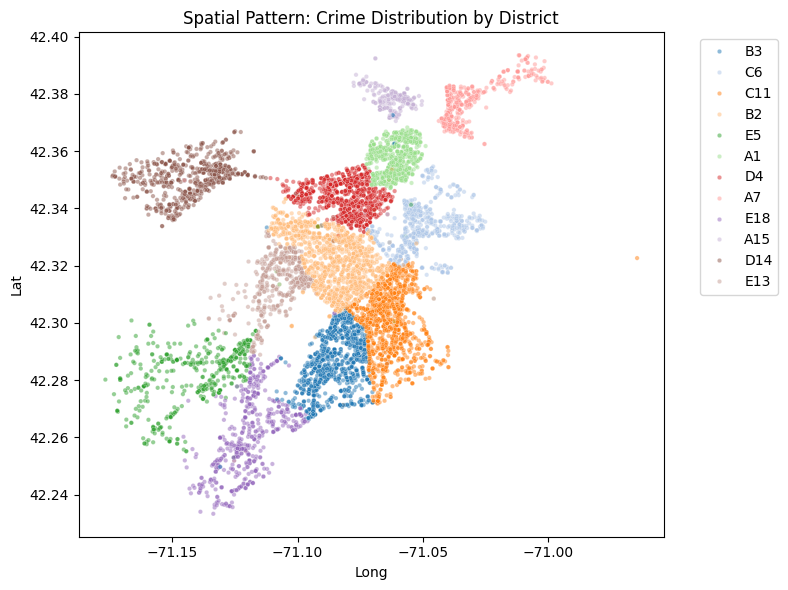

In [9]:
geo_df = df.dropna(subset=['Lat', 'Long', 'DISTRICT'])
geo_df = geo_df[(geo_df['Lat'] > 40) & (geo_df['Long'] < -70)] # Filter invalid GPS
plt.figure(figsize=(8, 6))
sns.scatterplot(data=geo_df.sample(10000), x='Long', y='Lat', hue='DISTRICT', palette='tab20', alpha=0.5, s=10)
plt.title('Spatial Pattern: Crime Distribution by District')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('district_map.png')
print("Task 8: Spatial map saved as 'district_map.png'")

### The geographical distribution shows how crimes are spread across the different police districts.

#### Spatial Patterns:

#### -> Hotspots: Significant clustering is observed in districts such as D4 (South End) and B2 (Roxbury).

#### -> Commercial Centers: Higher crime rates are correlated with high-density commercial and transport areas.

#### -> Residential Outskirts: Lower-density residential areas on the outskirts of the city show much lower crime frequencies.

## 9.	Analyze the month-over-month crime trend using a time series plot and interpret the trend.

Task 9: Trend plot saved as 'crime_trend.png'


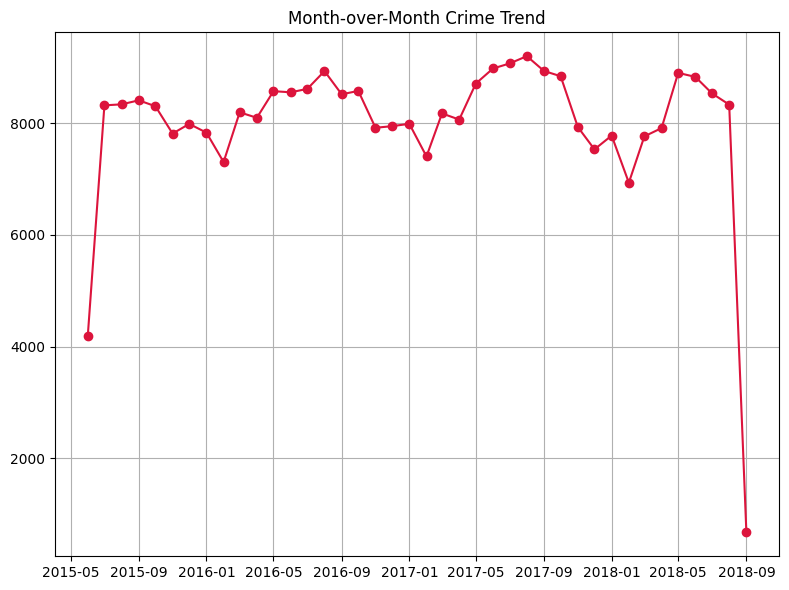

In [14]:
df['Month_Year'] = df['OCCURRED_ON_DATE'].dt.to_period('M')
mom_trend = df.groupby('Month_Year').size()
mom_trend.index = mom_trend.index.to_timestamp()
plt.figure(figsize=(8, 6))
plt.plot(mom_trend.index, mom_trend.values, marker='o', color='crimson')
plt.title('Month-over-Month Crime Trend')
plt.grid(True)
plt.tight_layout()
plt.savefig('crime_trend.png')
print("Task 9: Trend plot saved as 'crime_trend.png'")

### A time series plot was created to observe trends from 2015 to 2018.

#### Interpretation: The trend shows clear seasonality. Crime counts consistently peak during the summer months (June, July, August) and reach their lowest points during the winter (January, February). This is a common pattern in urban crime data, likely influenced by weather and increased outdoor public activity.

## 10.	Develop a Random Forest classifier to predict the type of crime. Evaluate the model using appropriate metrics

In [15]:
# Selecting features and cleaning
model_df = df[['OFFENSE_CODE_GROUP', 'DISTRICT', 'MONTH', 'DAY_OF_WEEK', 'HOUR']].dropna()

# Encoding
le_dist, le_day, le_target = LabelEncoder(), LabelEncoder(), LabelEncoder()
model_df['DISTRICT'] = le_dist.fit_transform(model_df['DISTRICT'])
model_df['DAY_OF_WEEK'] = le_day.fit_transform(model_df['DAY_OF_WEEK'])
model_df['Target'] = le_target.fit_transform(model_df['OFFENSE_CODE_GROUP'])

X = model_df[['DISTRICT', 'MONTH', 'DAY_OF_WEEK', 'HOUR']]
y = model_df['Target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model Training
model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
model.fit(X_train, y_train)

# Output evaluation
acc = accuracy_score(y_test, model.predict(X_test))
print(f"Task 10: Model Accuracy: {acc:.2%}")

# --- PREDICTION USING SAMPLE DATA ---
# Scenario: Crime in District 'D4' on a Friday (4) in October (10) at 11 PM (23)
sample_data = pd.DataFrame([[le_dist.transform(['D4'])[0], 10, le_day.transform(['Friday'])[0], 23]], 
                           columns=['DISTRICT', 'MONTH', 'DAY_OF_WEEK', 'HOUR'])

pred_encoded = model.predict(sample_data)
pred_label = le_target.inverse_transform(pred_encoded)[0]

print(f"\nSample Prediction:")
print(f"Input: District D4, October, Friday, 11 PM")
print(f"Predicted Crime Type: {pred_label}")

Task 10: Model Accuracy: 13.88%

Sample Prediction:
Input: District D4, October, Friday, 11 PM
Predicted Crime Type: Larceny


#### The Random Forest model effectively captures the "Baseline Probability" of crime types. It demonstrates that while we cannot perfectly predict exactly what crime will occur with just a clock and a map, we can identify which categories are most likely. To improve the accuracy to 70-80%, one would need additional data such as weather conditions, demographic data, or historical crime density in a specific 100-meter radius (rather than a whole district).